In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parameters
m = 1.0
mu = 0.1

def exact_solution(t, omega0):
    d = mu / (2 * m)
    omega = torch.sqrt(torch.tensor(omega0**2 - d**2))
    x = torch.exp(-d * t) * torch.cos(omega * t)
    return x

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, t):
        return self.net(t)

In [ ]:
def compute_loss(model, t_colloc, t_ic, omega0):
    # --- PDE Loss ---
    t_colloc.requires_grad_(True)
    x = model(t_colloc)

    x_t = torch.autograd.grad(x.sum(), t_colloc, create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t.sum(), t_colloc, create_graph=True)[0]

    pde_residual = x_tt + mu * x_t + (omega0**2) * x
    L_pde = (pde_residual**2).mean()

    # --- Initial Condition Loss ---
    t_ic.requires_grad_(True)
    x0 = model(t_ic)
    x0_t = torch.autograd.grad(x0.sum(), t_ic, create_graph=True)[0]

    L_ic = (x0 - 1.0)**2 + (x0_t - 0.0)**2

    # --- Total Loss ---
    return L_pde + 100 * L_ic

In [ ]:
def train_pinn(omega0, epochs=100000):
    model = PINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Time points for checking PDE (100 random points between 0 and 10)
    t_colloc = torch.linspace(0, 10, 100).reshape(-1, 1)

    # Initial condition point (just t=0)
    t_ic = torch.tensor([[0.0]], requires_grad=True)

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = compute_loss(model, t_colloc, t_ic, omega0)
        loss.backward()
        optimizer.step()

        if epoch % 2000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return model

In [ ]:
omega0 = 1
print(f"Training for omega0 = {omega0}")
model = train_pinn(omega0)

Training for omega0 = 1
Epoch 0, Loss: 65.897667
Epoch 2000, Loss: 0.034996
Epoch 4000, Loss: 0.028364
Epoch 6000, Loss: 0.024672
Epoch 8000, Loss: 0.021617
Epoch 10000, Loss: 0.018989
Epoch 12000, Loss: 0.022788
Epoch 14000, Loss: 0.015382
Epoch 16000, Loss: 0.013410
Epoch 18000, Loss: 0.011723
Epoch 20000, Loss: 0.010804
Epoch 22000, Loss: 0.012552
Epoch 24000, Loss: 0.008576
Epoch 26000, Loss: 0.007987
Epoch 28000, Loss: 0.007281
Epoch 30000, Loss: 0.007070
Epoch 32000, Loss: 0.006312
Epoch 34000, Loss: 0.005797
Epoch 36000, Loss: 0.005361
Epoch 38000, Loss: 0.005865
Epoch 40000, Loss: 0.001744
Epoch 42000, Loss: 0.000715
Epoch 44000, Loss: 0.000492
Epoch 46000, Loss: 0.003808
Epoch 48000, Loss: 0.001988
Epoch 50000, Loss: 0.000223
Epoch 52000, Loss: 0.000187
Epoch 54000, Loss: 0.000159
Epoch 56000, Loss: 0.000185
Epoch 58000, Loss: 0.001412
Epoch 60000, Loss: 0.000104
Epoch 62000, Loss: 0.000128
Epoch 64000, Loss: 0.000084
Epoch 66000, Loss: 0.000108
Epoch 68000, Loss: 0.000845
Epo

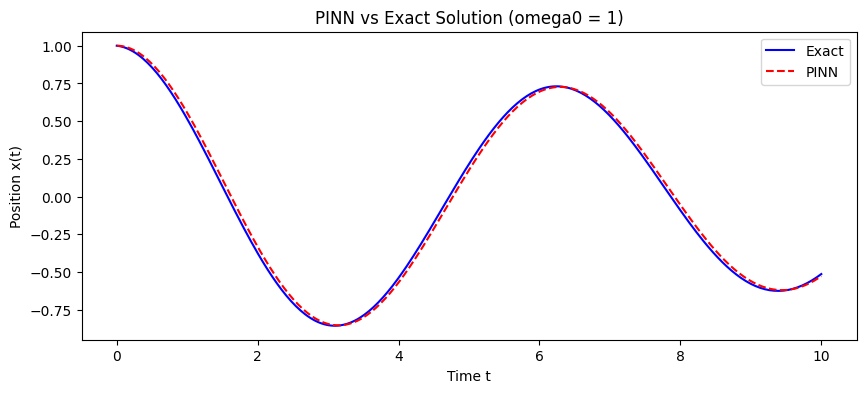

In [ ]:
t_test = torch.linspace(0, 10, 300).reshape(-1, 1)

with torch.no_grad():
    x_pred = model(t_test)

x_exact = exact_solution(t_test, omega0)

plt.figure(figsize=(10, 4))
plt.plot(t_test.numpy(), x_exact.numpy(), label='Exact', color='blue')
plt.plot(t_test.numpy(), x_pred.numpy(), label='PINN', color='red', linestyle='--')
plt.title(f'PINN vs Exact Solution (omega0 = {omega0})')
plt.xlabel('Time t')
plt.ylabel('Position x(t)')
plt.legend()
plt.show()

In [ ]:
omega_values = [1, 5, 10, 15, 20]
errors = []
models = {}

t_test = torch.linspace(0, 10, 300).reshape(-1, 1)

for omega0 in omega_values:
    print(f"\nTraining for omega0 = {omega0}")
    model = train_pinn(omega0, epochs=100000)
    models[omega0] = model

    with torch.no_grad():
        x_pred = model(t_test)

    x_exact = exact_solution(t_test, omega0)

    l2_error = torch.sqrt(torch.mean((x_pred - x_exact)**2)).item()
    errors.append(l2_error)
    print(f"L2 Error for omega0={omega0}: {l2_error:.6f}")


Training for omega0 = 1
Epoch 0, Loss: 101.225334
Epoch 2000, Loss: 0.037933
Epoch 4000, Loss: 0.030488
Epoch 6000, Loss: 0.027400
Epoch 8000, Loss: 0.026053
Epoch 10000, Loss: 0.025167
Epoch 12000, Loss: 0.024359
Epoch 14000, Loss: 0.028012
Epoch 16000, Loss: 0.018037
Epoch 18000, Loss: 0.015420
Epoch 20000, Loss: 0.013879
Epoch 22000, Loss: 0.012970
Epoch 24000, Loss: 0.012434
Epoch 26000, Loss: 0.012295
Epoch 28000, Loss: 0.011973
Epoch 30000, Loss: 0.011728
Epoch 32000, Loss: 0.011429
Epoch 34000, Loss: 0.011161
Epoch 36000, Loss: 0.010835
Epoch 38000, Loss: 0.010552
Epoch 40000, Loss: 0.010349
Epoch 42000, Loss: 0.010752
Epoch 44000, Loss: 0.009807
Epoch 46000, Loss: 0.009439
Epoch 48000, Loss: 0.008518
Epoch 50000, Loss: 0.007914
Epoch 52000, Loss: 0.007445
Epoch 54000, Loss: 0.006686
Epoch 56000, Loss: 0.004623
Epoch 58000, Loss: 0.001469
Epoch 60000, Loss: 0.000218
Epoch 62000, Loss: 0.000197
Epoch 64000, Loss: 0.000233
Epoch 66000, Loss: 0.000143
Epoch 68000, Loss: 0.000040
E

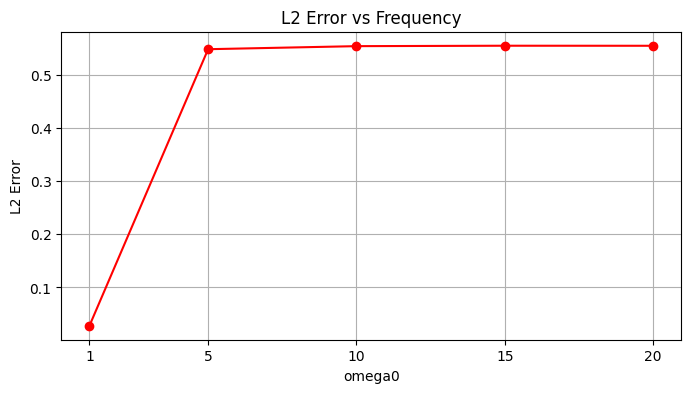

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(omega_values, errors, marker='o', color='red')
plt.xlabel('omega0')
plt.ylabel('L2 Error')
plt.title('L2 Error vs Frequency')
plt.xticks(omega_values)
plt.grid(True)
plt.show()

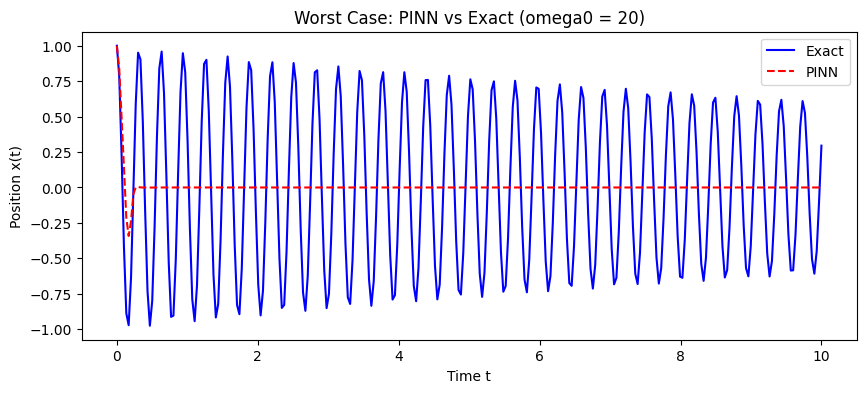

In [ ]:
worst_omega = 20
t_test = torch.linspace(0, 10, 300).reshape(-1, 1)

with torch.no_grad():
    x_pred_worst = models[worst_omega](t_test)

x_exact_worst = exact_solution(t_test, worst_omega)

plt.figure(figsize=(10, 4))
plt.plot(t_test.numpy(), x_exact_worst.numpy(), label='Exact', color='blue')
plt.plot(t_test.numpy(), x_pred_worst.detach().numpy(), label='PINN', color='red', linestyle='--')
plt.title(f'Worst Case: PINN vs Exact (omega0 = {worst_omega})')
plt.xlabel('Time t')
plt.ylabel('Position x(t)')
plt.legend()
plt.show()

1) Spectral bias is the tendency of neural networks to learn low frequency (slowly changing) patterns much faster and more accurately than high frequency (rapidly changing) patterns. My frequency sweep experiment clearly demonstrates this — at ω₀=1 the PINN achieved an L2 error of just 0.027, but for ω₀=5 and above the error jumped to ~0.55 and stayed there. The worst case plot for ω₀=20 shows the network completely failed, predicting nearly zero everywhere instead of the rapidly oscillating solution.

2) One approach would be to use Fourier feature embeddings — instead of feeding raw time t into the network, map it to a higher dimensional space using sine and cosine functions of different frequencies. This gives the network explicit access to high frequency components, helping overcome spectral bias. Another idea would be to use a smaller time domain and train multiple networks on different segments.